# Multi-Float Simulation Error Analysis

Discovers Argo floats that operated inside the CMEMS model domain, downloads their trajectory
files, reruns the simulation against each one using the **reset-per-cycle** approach, and
aggregates the position errors across all floats.

**Workflow:**
1. **Cell 1** — reads `manifest.yaml`, queries the Argo index, shows a map of floats in the domain.
2. **Cell 2** — edit `WMOS_TO_ANALYZE` with WMOs from the map.
3. **Cell 3** — downloads `{WMO}_Rtraj.nc` from the Argo GDAC for each selected float.
4. **Cells 4–7** — setup, helpers, simulation loop, aggregate plots.

Run all: `Kernel › Restart & Run All`

In [7]:
# ── Cell 1: Discover floats in the CMEMS domain ──────────────────────────────
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import plotly.graph_objects as go

_src_dir = Path("~/Documents/argo_piloting/sim/src").expanduser()
if str(_src_dir) not in sys.path:
    sys.path.insert(0, str(_src_dir))
from data_loader import load_manifest

DATA_DIR      = Path("~/Documents/argo_piloting/sim/data/raw").expanduser()
ARGO_DATA_DIR = Path("~/Documents/argo_piloting/sim/data/argo_data").expanduser()

# ── Derive CMEMS domain from manifest ────────────────────────────────────────
manifest = load_manifest(DATA_DIR)

lat_min = min(e["lat"][0] for e in manifest)
lat_max = max(e["lat"][1] for e in manifest)
lon_min = min(e["lon"][0] for e in manifest)
lon_max = max(e["lon"][1] for e in manifest)
t_start = min(datetime.fromisoformat(e["time"][0]) for e in manifest)
t_end   = max(datetime.fromisoformat(e["time"][1]) for e in manifest)

print(f"CMEMS domain : lat=[{lat_min:.2f}, {lat_max:.2f}]  lon=[{lon_min:.2f}, {lon_max:.2f}]")
print(f"Time window  : {t_start.date()} → {t_end.date()}")

# ── Load Argo global index and filter to CMEMS domain ────────────────────────
from argopy import ArgoIndex

print("\nLoading Argo global index...")
df_all = ArgoIndex().load().to_dataframe()

mask = (
    (df_all["latitude"]  >= lat_min) & (df_all["latitude"]  <= lat_max) &
    (df_all["longitude"] >= lon_min) & (df_all["longitude"] <= lon_max) &
    (df_all["date"] >= pd.Timestamp(t_start)) &
    (df_all["date"] <= pd.Timestamp(t_end))
)
_df = df_all[mask].copy()

_wmo_to_dac = _df.drop_duplicates("wmo").set_index("wmo")["dac"].to_dict()

summary = (
    _df.groupby("wmo")
    .agg(n_profiles=("date", "count"),
         first_profile=("date", "min"),
         last_profile=("date", "max"))
    .sort_values("n_profiles", ascending=False)
    .reset_index()
)

print(f"\nFound {len(summary)} floats with {len(_df)} total profiles:")
print(summary.to_string(index=False))

# ── Map ───────────────────────────────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scattergeo(
    lon=[lon_min, lon_max, lon_max, lon_min, lon_min],
    lat=[lat_min, lat_min, lat_max, lat_max, lat_min],
    mode="lines", line=dict(color="cyan", width=2, dash="dash"),
    name="CMEMS domain",
))
for wmo in summary["wmo"]:
    pts = _df[_df["wmo"] == wmo].sort_values("date")
    fig.add_trace(go.Scattergeo(
        lon=pts["longitude"], lat=pts["latitude"],
        mode="lines+markers", marker=dict(size=3), line=dict(width=1),
        name=str(wmo),
        hovertemplate=f"WMO {wmo}<br>%{{lat:.3f}}°N %{{lon:.3f}}°E<extra></extra>",
    ))
fig.update_layout(
    title=f"Argo floats in CMEMS domain — {len(summary)} floats",
    geo=dict(
        scope="europe",
        center=dict(lat=(lat_min + lat_max) / 2, lon=(lon_min + lon_max) / 2),
        projection_scale=6,
        showland=True,  landcolor="rgb(40,40,40)",
        showocean=True, oceancolor="rgb(10,30,60)",
        showcoastlines=True, coastlinecolor="grey", showframe=False,
    ),
    paper_bgcolor="rgb(15,20,40)", font_color="white", height=600,
    legend=dict(title="WMO", bgcolor="rgba(0,0,0,0.5)"),
)
fig.show()

CMEMS domain : lat=[53.50, 56.50]  lon=[12.50, 18.00]
Time window  : 2023-10-01 → 2025-01-31

Loading Argo global index...

Found 6 floats with 1068 total profiles:
    wmo  n_profiles       first_profile        last_profile
4903784         317 2023-11-07 20:40:05 2025-01-27 11:50:38
3902117         285 2023-10-01 08:14:30 2024-02-24 06:20:30
2903902         175 2024-03-22 18:11:31 2025-01-26 13:43:28
1902682         154 2023-10-02 09:28:30 2024-02-23 19:25:00
7902194         120 2024-05-28 12:02:00 2025-01-31 19:31:30
7900584          17 2023-10-03 10:29:10 2023-12-22 10:38:51


In [8]:
# ── Cell 2: Select floats to analyse ─────────────────────────────────────────
# Add WMO numbers from the map above.
WMOS_TO_ANALYZE = [
    7902194,
    4903784,
    1902682,
    7900584,
    3902117
]

In [3]:
# ── Cell 3: Download Rtraj and Profiles files ─────────────────────────────────
import urllib.request
from argopy import DataFetcher as ArgoDataFetcher

try:
    wmo_to_dac = _wmo_to_dac
except NameError:
    print("Re-loading Argo index for DAC info...")
    import pandas as pd
    from argopy import ArgoIndex
    _fb = ArgoIndex().load().to_dataframe()
    wmo_to_dac = _fb.drop_duplicates("wmo").set_index("wmo")["dac"].to_dict()

for wmo in WMOS_TO_ANALYZE:
    out_dir = ARGO_DATA_DIR / f"argo_{wmo}"
    out_dir.mkdir(parents=True, exist_ok=True)
    dac = wmo_to_dac.get(wmo)

    # Rtraj: download from GDAC
    rtraj_path = out_dir / f"{wmo}_Rtraj.nc"
    if rtraj_path.exists():
        print(f"WMO {wmo}: Rtraj.nc already present — skipping.")
    elif dac is None:
        print(f"WMO {wmo}: DAC not found — cannot download Rtraj.")
    else:
        url = f"https://data-argo.ifremer.fr/dac/{dac}/{wmo}/{wmo}_Rtraj.nc"
        print(f"WMO {wmo}: downloading Rtraj.nc ...")
        urllib.request.urlretrieve(url, rtraj_path)
        print(f"WMO {wmo}: saved {rtraj_path.stat().st_size/1e6:.1f} MB")

    # profiles.nc: fetch via argopy (erddap) — gives DIRECTION as <U1 and POSITION_QC as int64
    prof_path = out_dir / f"{wmo}_profiles.nc"
    if prof_path.exists():
        print(f"WMO {wmo}: profiles.nc already present — skipping.")
    else:
        print(f"WMO {wmo}: fetching profiles.nc via argopy ...")
        try:
            ds_prof = ArgoDataFetcher(src="erddap").float(wmo).load().data
            ds_prof.to_netcdf(prof_path)
            print(f"WMO {wmo}: saved profiles.nc ({prof_path.stat().st_size/1e6:.1f} MB)")
        except Exception as e:
            print(f"WMO {wmo}: profiles.nc fetch failed — {e}")

print("Done.")

WMO 7902194: Rtraj.nc already present — skipping.
WMO 7902194: profiles.nc already present — skipping.
WMO 4903784: Rtraj.nc already present — skipping.
WMO 4903784: profiles.nc already present — skipping.
WMO 1902682: Rtraj.nc already present — skipping.
WMO 1902682: profiles.nc already present — skipping.
WMO 7900584: Rtraj.nc already present — skipping.
WMO 7900584: profiles.nc already present — skipping.
WMO 3902117: Rtraj.nc already present — skipping.
WMO 3902117: profiles.nc already present — skipping.
Done.


In [20]:
# ── Cell 4: Setup — imports, manifest, bathymetry ─────────────────────────────
import math
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import sys
from pathlib import Path

_nb_dir  = Path("~/Documents/argo_piloting/sim/notebooks/Q_derivation").expanduser()
_src_dir = Path("~/Documents/argo_piloting/sim/src").expanduser()
# nb_dir inserted last → ends up at sys.path[0], so local sim_types/particle_mover
# shadow the src versions; data_loader falls through to src.
for p in [str(_src_dir), str(_nb_dir)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from sim_types import ControlAction, GeoLocation, ProfilerState
from particle_mover import run_until_next_action
from data_loader import (
    load_manifest, load_bathymetry, build_bathymetry_interpolator
)

DATA_DIR      = Path("~/Documents/argo_piloting/sim/data/raw").expanduser()
ARGO_DATA_DIR = Path("~/Documents/argo_piloting/sim/data/argo_data").expanduser()
BATHY_PATH    = DATA_DIR / "D6_2024.nc"

manifest     = load_manifest(DATA_DIR)
bathy_ds     = load_bathymetry(BATHY_PATH)
bathy_interp = build_bathymetry_interpolator(bathy_ds)

t_start = min(datetime.fromisoformat(e["time"][0]) for e in manifest)
t_end   = max(datetime.fromisoformat(e["time"][1]) for e in manifest)

print(f"Manifest: {len(manifest)} tiles | CMEMS window: {t_start.date()} → {t_end.date()}")
print("Bathymetry loaded.")

Manifest: 400 tiles | CMEMS window: 2023-10-01 → 2025-01-31
Bathymetry loaded.


In [25]:
# -- Cell 5: Helper functions ------------------------------------------------

DESC_CODE    = 190
PARKING_CODE = 290
ASC_CODE     = 590

DRIFT_THRESH_KM   = 1.0   # surface drift <= this -> parked_on_bottom
DEPTH_FRAC_THRESH = 0.95  # avg_parking_depth / bathy >= this -> parked_on_bottom


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 6371.0 * 2 * math.asin(math.sqrt(a))


def _speed_from_pres_juld(sub_ds):
    pres = sub_ds.PRES.values.astype(float)
    juld = sub_ds.JULD.values
    dt_s = np.diff(juld) / np.timedelta64(1, 's')
    valid = dt_s != 0
    if not valid.any():
        return None
    return float(np.nanmean(np.diff(pres)[valid] / dt_s[valid]))


def _build_profile_pos(profiles_path):
    """Build cycle -> (lat, lon) from ascending profiles, preferring QC=1.
    Handles argopy format (_profiles.nc, unicode + int64) and
    GDAC format (_prof.nc, bytes/object)."""
    ds_p = xr.open_dataset(profiles_path).load()
    direction = ds_p['DIRECTION'].values
    if direction.dtype == object:  # GDAC bytes: b'A'
        asc_mask = np.array([d == b'A' for d in direction])
    else:                          # argopy unicode: 'A'
        asc_mask = direction == 'A'
    prof_cyc = ds_p['CYCLE_NUMBER'].values[asc_mask].astype(int)
    prof_lat = ds_p['LATITUDE'].values[asc_mask].astype(float)
    prof_lon = ds_p['LONGITUDE'].values[asc_mask].astype(float)
    raw_qc   = ds_p['POSITION_QC'].values[asc_mask]
    try:
        prof_qc = raw_qc.astype(int)
    except (ValueError, TypeError):
        prof_qc = np.array([int(q.decode().strip()) if isinstance(q, bytes)
                            else int(str(q).strip()) for q in raw_qc])
    pos = {}
    for c in np.unique(prof_cyc):
        idx  = np.where(prof_cyc == c)[0]
        good = idx[prof_qc[idx] == 1]
        use  = good if len(good) else idx
        pos[int(c)] = (float(prof_lat[use[0]]), float(prof_lon[use[0]]))
    return pos


def _robust_start_pos(cycle_ds):
    """Fallback position using code-703 GPS fixes when no profiles file has an entry.
    Mirrors the exact approach used in argo_data_analyser.ipynb."""
    mask_703 = cycle_ds.MEASUREMENT_CODE.values == 703
    lats = cycle_ds.LATITUDE.values.astype(float)[mask_703]
    lons = cycle_ds.LONGITUDE.values.astype(float)[mask_703]
    j    = cycle_ds.JULD.values.astype(float)[mask_703]
    valid = ~np.isnan(lats) & ~np.isnan(lons) & ~np.isnan(j)
    if not valid.any():
        all_lat = cycle_ds.LATITUDE.values.astype(float)
        all_lon = cycle_ds.LONGITUDE.values.astype(float)
        v = ~np.isnan(all_lat) & ~np.isnan(all_lon)
        return (float(np.median(all_lat[v])), float(np.median(all_lon[v]))) if v.any() else (None, None)
    lats, lons, j = lats[valid], lons[valid], j[valid]
    order = np.argsort(j)
    lats, lons, j = lats[order], lons[order], j[order]
    if len(lats) == 1:
        return float(lats[0]), float(lons[0])
    t_sec     = (j - j[0]) * 86400
    within_30 = t_sec[1:] <= 30
    close     = (np.abs(lons[1:] - lons[0]) <= 0.3) & (np.abs(lats[1:] - lats[0]) <= 0.3)
    confirmed = (within_30 & close).any()
    if confirmed:
        early = (t_sec <= 60) & (np.abs(lons - lons[0]) <= 0.5) & (np.abs(lats - lats[0]) <= 0.5)
        return float(np.mean(lats[early])), float(np.mean(lons[early]))
    else:
        return float(np.median(lats[1:])), float(np.median(lons[1:]))


def extract_cycles(rtraj_path, bathy_interp):
    """Derive per-cycle metadata from an Argo Rtraj NetCDF file."""
    rtraj_path = Path(rtraj_path)
    ds = xr.open_dataset(rtraj_path)

    # Try _profiles.nc (argopy format) first, then _prof.nc (GDAC format)
    wmo_stem = rtraj_path.name.replace('_Rtraj.nc', '')
    for suffix in ('_loologlal','_profiles.nc'):
        candidate = rtraj_path.parent / (wmo_stem + suffix)
        print(candidate)
        if candidate.exists():
            profile_pos = _build_profile_pos(candidate)
            print(f'  Profile positions: {len(profile_pos)} cycles from {candidate.name}')
            break
    else:
        profile_pos = {}
        print(f'  No profiles file found -- using Rtraj fallback for all cycles')

    all_cycles = [int(c) for c in np.unique(ds.CYCLE_NUMBER.values)
                  if not np.isnan(float(c))]
    cycle_numbers = sorted(all_cycles)

    # -- Pass 1: per-cycle positions, timing, speeds, parking depth -----------
    meta = {}
    for cyc in cycle_numbers:
        mask   = ds.CYCLE_NUMBER.values == cyc
        cyc_ds = ds.isel(N_MEASUREMENT=mask)
        juld   = cyc_ds.JULD.values
        valid_t = juld[~np.isnat(juld)]
        if len(valid_t) == 0:
            continue

        codes   = cyc_ds.MEASUREMENT_CODE.values
        desc_ds = cyc_ds.isel(N_MEASUREMENT=codes == DESC_CODE)
        asc_ds  = cyc_ds.isel(N_MEASUREMENT=codes == ASC_CODE)
        park_ds = cyc_ds.isel(N_MEASUREMENT=codes == PARKING_CODE)

        desc_t = desc_ds.JULD.values; desc_t = desc_t[~np.isnat(desc_t)]
        asc_t  = asc_ds.JULD.values;  asc_t  = asc_t[~np.isnat(asc_t)]

        # Start position: profiles file (preferred) or robust Rtraj fallback
        if cyc in profile_pos:
            start_lat, start_lon = profile_pos[cyc]
        else:
            start_lat, start_lon = _robust_start_pos(cyc_ds)
            if start_lat is None:
                continue

        # Last Rtraj position -- used for surface-window drift in Pass 2
        all_lats = cyc_ds.LATITUDE.values.astype(float)
        all_lons = cyc_ds.LONGITUDE.values.astype(float)
        pos_mask = ~np.isnan(all_lats) & ~np.isnan(all_lons)
        last_lat = float(all_lats[pos_mask][-1]) if pos_mask.any() else start_lat
        last_lon = float(all_lons[pos_mask][-1]) if pos_mask.any() else start_lon

        pres = park_ds.PRES.values.astype(float)
        pres = pres[~np.isnan(pres)]

        bathy_depth_m = float(bathy_interp(start_lat, start_lon))

        depth_based_parked = False
        avg_bottom_depth_dbar = None
        if len(pres) > 0:
            avg_bottom_depth_dbar = float(np.mean(pres))
            if not math.isnan(bathy_depth_m) and bathy_depth_m > 0:
                depth_based_parked = bool(
                    avg_bottom_depth_dbar / bathy_depth_m >= DEPTH_FRAC_THRESH
                )

        meta[cyc] = dict(
            cycle=cyc,
            start_lat=start_lat,
            start_lon=start_lon,
            last_lat=last_lat,
            last_lon=last_lon,
            start_time=str(valid_t[0]),
            end_time=str(valid_t[-1]),
            first_desc_juld=desc_t[0] if len(desc_t) > 0 else valid_t[0],
            last_asc_juld=asc_t[-1]   if len(asc_t)  > 0 else valid_t[-1],
            descent_speed_dbar_s=_speed_from_pres_juld(desc_ds)
                                 if len(desc_ds.N_MEASUREMENT) >= 2 else None,
            ascent_speed_dbar_s=_speed_from_pres_juld(asc_ds)
                                if len(asc_ds.N_MEASUREMENT) >= 2 else None,
            avg_bottom_depth_dbar=avg_bottom_depth_dbar,
            bathy_depth_m=bathy_depth_m,
            depth_based_parked=depth_based_parked,
            parked_on_bottom=False,   # overwritten in Pass 2
        )

    # -- Pass 2: surface drift + depth match -> parked_on_bottom --------------
    for i, cyc in enumerate(cycle_numbers[:-1]):
        nxt = cycle_numbers[i + 1]
        if cyc not in meta or nxt not in meta:
            continue
        m, nm = meta[cyc], meta[nxt]
        surf_min = float(
            (nm['first_desc_juld'] - m['last_asc_juld']) / np.timedelta64(1, 'm')
        )
        # Drift = end of cycle M's surface window -> start of cycle M+1
        dlat_m = (nm['start_lat'] - m['last_lat']) * 111320.0
        dlon_m = ((nm['start_lon'] - m['last_lon'])
                  * 111320.0 * math.cos(math.radians(m['last_lat'])))
        drift_km = math.sqrt(dlat_m ** 2 + dlon_m ** 2) / 1000.0
        m['surface_duration_min'] = round(max(surf_min, 0.0), 1)
        m['drift_km']             = round(drift_km, 3)
        m['parked_on_bottom']     = (drift_km <= DRIFT_THRESH_KM) or m.get('depth_based_parked', False)

    # Default for last cycle
    if cycle_numbers and cycle_numbers[-1] in meta:
        last = meta[cycle_numbers[-1]]
        last.setdefault('surface_duration_min', 30.0)
        last.setdefault('drift_km', None)
        last.setdefault('parked_on_bottom', False)

    # -- Fill missing speeds with per-float mean -------------------------------
    desc_speeds = [v['descent_speed_dbar_s'] for v in meta.values()
                   if v['descent_speed_dbar_s'] is not None]
    asc_speeds  = [v['ascent_speed_dbar_s']  for v in meta.values()
                   if v['ascent_speed_dbar_s']  is not None]
    mean_desc = float(np.mean(desc_speeds)) if desc_speeds else 0.08
    mean_asc  = float(np.mean(asc_speeds))  if asc_speeds  else 0.08
    for v in meta.values():
        if v['descent_speed_dbar_s'] is None:
            v['descent_speed_dbar_s'] = mean_desc
        if v['ascent_speed_dbar_s'] is None:
            v['ascent_speed_dbar_s'] = mean_asc

    ds.close()
    return [meta[c] for c in cycle_numbers if c in meta]


def action_from_cycle(cyc, next_cyc):
    """Build a ControlAction from a cycle dict and the following cycle dict."""
    t_start  = np.datetime64(cyc['start_time'])
    t_next   = np.datetime64(next_cyc['start_time'])
    surf_min = float(cyc.get('surface_duration_min') or 30.0)

    try:
        asc_s = cyc['avg_bottom_depth_dbar'] / abs(cyc['ascent_speed_dbar_s'])
        cycle_hours = float(
            (t_next - t_start
             - np.timedelta64(int(surf_min), 'm')
             - np.timedelta64(int(asc_s), 's'))
            / np.timedelta64(1, 'h')
        )
    except Exception:
        cycle_hours = float((t_next - t_start) / np.timedelta64(1, 'h'))

    if cyc.get('parked_on_bottom', False):
        park_mode = 'park_on_bottom'
    elif cyc.get('avg_bottom_depth_dbar') is not None:
        park_mode = 'parking_depth'
    else:
        park_mode = 'drift_on_surface'

    return ControlAction(
        park_mode=park_mode,
        cycle_hours=max(cycle_hours, 0.5),
        transmission_duration_minutes=surf_min,
        target_depth=cyc.get('avg_bottom_depth_dbar'),
        descent_speed_ms=abs(cyc['descent_speed_dbar_s']),
        ascent_speed_ms=abs(cyc['ascent_speed_dbar_s']),
    )


print('Helpers defined.')


Helpers defined.


In [26]:
# ── Cell 6: Run reset simulation for every float and cycle ────────────────────
MAX_DEPTH_M  = 150   # skip cycles with unrealistic or unknown parking depth
FORCE_RERUN  = True  # set False to load from cache after first run
CACHE_PATH   = Path("~/Documents/argo_piloting/sim/notebooks/Q_derivation/multi_float_errors_cache_conservative_bottom_park.parquet").expanduser()

if not FORCE_RERUN and CACHE_PATH.exists():
    all_df = pd.read_parquet(CACHE_PATH)
    all_results = {
        wmo: all_df[all_df["wmo"] == wmo].to_dict("records")
        for wmo in all_df["wmo"].unique()
    }
    print(f"Loaded {len(all_df)} rows from cache ({CACHE_PATH.name}).")
    print(f"Floats: {sorted(all_df['wmo'].unique())}  |  cycles: {len(all_df)}")
else:
    t_start_np = np.datetime64(t_start)
    t_end_np   = np.datetime64(t_end)

    all_results = {}

    for wmo in WMOS_TO_ANALYZE:
        rtraj_path = ARGO_DATA_DIR / f"argo_{wmo}" / f"{wmo}_Rtraj.nc"
        if not rtraj_path.exists():
            print(f"WMO {wmo}: Rtraj not found — skipping (run Cell 3 first).")
            continue

        print(f"\nWMO {wmo}: extracting cycles...")
        cycles = extract_cycles(rtraj_path, bathy_interp)
        cycles = [c for c in cycles
                  if t_start_np <= np.datetime64(c["start_time"]) <= t_end_np]
        print(f"  {len(cycles)} cycles in CMEMS window")

        float_errors = []
        for i, cyc in enumerate(cycles[:-1]):
            next_cyc = cycles[i + 1]
            try:
                action = action_from_cycle(cyc, next_cyc)

                # Skip cycles that would cause runaway descent:
                #   (a) explicit parking depth exceeds the cap
                target_depth = cyc.get("avg_bottom_depth_dbar") or 0.0
                if target_depth > MAX_DEPTH_M:
                    print(f"  Cycle {cyc['cycle']}: skipping — target depth {target_depth:.0f} m > {MAX_DEPTH_M} m limit")
                    continue
                #   (b) park_on_bottom with unknown/unreliable bathymetry → infinite descent
                bathy_depth = cyc.get("bathy_depth_m", float("nan"))
                if cyc.get("parked_on_bottom") and (math.isnan(bathy_depth) or bathy_depth > MAX_DEPTH_M):
                    print(f"  Cycle {cyc['cycle']}: skipping — park_on_bottom with bathy={bathy_depth:.0f} m")
                    continue

                start_dt = pd.Timestamp(cyc["start_time"]).to_pydatetime().replace(tzinfo=None)
                state = ProfilerState(
                    time=start_dt,
                    location=GeoLocation(lat=cyc["start_lat"], lon=cyc["start_lon"]),
                    depth=0.0,
                    phase="communicating",
                    x=0.0,
                    y=0.0,
                    bathymetry_depth=bathy_interp(cyc["start_lat"], cyc["start_lon"]),
                )

                _, end_state = run_until_next_action(
                    state, DATA_DIR, manifest, bathy_interp, action,
                    dt_vertical_seconds=30,
                )
                error_km = haversine_km(
                    end_state.location.lat, end_state.location.lon,
                    next_cyc["start_lat"], next_cyc["start_lon"],
                )

                x_res_m = ((next_cyc["start_lon"] - end_state.location.lon)
                           * 111_320.0 * math.cos(math.radians(next_cyc["start_lat"])))
                y_res_m = (next_cyc["start_lat"] - end_state.location.lat) * 111_320.0

                T_s = (pd.Timestamp(next_cyc["start_time"])
                       - pd.Timestamp(cyc["start_time"])).total_seconds()
                depth     = cyc.get("avg_bottom_depth_dbar") or 0.0
                v_desc    = abs(cyc["descent_speed_dbar_s"])
                v_asc     = abs(cyc["ascent_speed_dbar_s"])
                T_transit = (depth / v_desc + depth / v_asc) if (depth > 0 and v_desc > 0 and v_asc > 0) else 0.0
                T_drift_s = max(T_s - T_transit, T_s * 0.5)

                float_errors.append({
                    "wmo":                  wmo,
                    "cycle":                cyc["cycle"],
                    "start_time":           cyc["start_time"],
                    "error_km":             error_km,
                    "sim_lat":              end_state.location.lat,
                    "sim_lon":              end_state.location.lon,
                    "real_lat":             next_cyc["start_lat"],
                    "real_lon":             next_cyc["start_lon"],
                    "park_mode":            action.park_mode,
                    "cycle_hours":          action.cycle_hours,
                    "x_res_m":              x_res_m,
                    "y_res_m":              y_res_m,
                    "T_s":                  T_s,
                    "T_drift_s":            T_drift_s,
                    "parked_on_bottom":     bool(cyc.get("parked_on_bottom", False)),
                    # diagnostic fields
                    "avg_bottom_depth_dbar": cyc.get("avg_bottom_depth_dbar"),
                    "bathy_depth_m":         cyc.get("bathy_depth_m"),
                    "drift_km":              cyc.get("drift_km"),
                    "surface_duration_min":  cyc.get("surface_duration_min"),
                })
            except Exception as exc:
                print(f"  Cycle {cyc['cycle']}: skipping — {exc}")

        all_results[wmo] = float_errors
        errs = [r["error_km"] for r in float_errors]
        if errs:
            print(f"  n={len(errs)} | "
                  f"mean={np.mean(errs):.2f} km | "
                  f"median={np.median(errs):.2f} km | "
                  f"max={np.max(errs):.2f} km")

    all_df = pd.DataFrame([r for rows in all_results.values() for r in rows])
    all_df.to_parquet(CACHE_PATH, index=False)
    print(f"\nTotal: {len(all_df)} cycles across {all_df['wmo'].nunique()} floats.")
    print(f"Saved to {CACHE_PATH.name}.")


WMO 7902194: extracting cycles...
/home/ddyob/Documents/argo_piloting/sim/data/argo_data/argo_7902194/7902194_loologlal
/home/ddyob/Documents/argo_piloting/sim/data/argo_data/argo_7902194/7902194_profiles.nc
  Profile positions: 343 cycles from 7902194_profiles.nc


/tmp/ipykernel_488484/1610659390.py:89: FutureWarning: In a future version, xarray will not decode the variable 'CLOCK_OFFSET' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(rtraj_path)


  122 cycles in CMEMS window


/tmp/ipykernel_488484/3426376413.py:50: UserWarning: Discarding nonzero nanoseconds in conversion.
  start_dt = pd.Timestamp(cyc["start_time"]).to_pydatetime().replace(tzinfo=None)
NaN velocity at lat=55.0727 lon=16.1752 depth=70.3 bathy=77.9 time=2024-06-18 18:26:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.0727 lon=16.1752 depth=71.4 bathy=77.9 time=2024-06-18 18:27:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.0727 lon=16.1752 depth=72.6 bathy=77.9 time=2024-06-18 18:27:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.0727 lon=16.1752 depth=73.7 bathy=77.9 time=2024-06-18 18:28:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.0727 lon=16.1752 depth=74.9 bathy=77.9 time=2024-06-18 18:28:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.0727 lon=16.1752 depth=76.0 bathy=77.9 time=2024-06-18 18:29:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.0727 lon=16.1752 depth

  n=121 | mean=1.31 km | median=0.89 km | max=17.42 km

WMO 4903784: extracting cycles...
/home/ddyob/Documents/argo_piloting/sim/data/argo_data/argo_4903784/4903784_loologlal
/home/ddyob/Documents/argo_piloting/sim/data/argo_data/argo_4903784/4903784_profiles.nc
  Profile positions: 187 cycles from 4903784_profiles.nc
  161 cycles in CMEMS window


...

  Cycle 35: skipping — No tiles found for lat=54.893 lon=18.757 time=[2023-12-22 11:18:24, 2023-12-27 22:12:33] margin=0.5°. Float may have left the dataset domain.
  Cycle 36: skipping — No tiles found for lat=54.695 lon=19.087 time=[2023-12-27 10:55:31, 2024-01-06 23:43:27] margin=0.5°. Float may have left the dataset domain.
  Cycle 38: skipping — No tiles found for lat=54.545 lon=19.049 time=[2024-01-06 12:21:29, 2024-01-11 22:21:00] margin=0.5°. Float may have left the dataset domain.
  Cycle 39: skipping — No tiles found for lat=54.761 lon=19.631 time=[2024-01-11 11:13:53, 2024-01-16 22:34:29] margin=0.5°. Float may have left the dataset domain.
  Cycle 40: skipping — No tiles found for lat=55.078 lon=19.983 time=[2024-01-16 11:22:28, 2024-01-21 22:11:47] margin=0.5°. Float may have left the dataset domain.
  Cycle 41: skipping — No tiles found for lat=55.150 lon=20.133 time=[2024-01-21 11:02:19, 2024-01-26 22:27:51] margin=0.5°. Float may have left the dataset domain.
  Cycle 42

/tmp/ipykernel_488484/1610659390.py:89: FutureWarning: In a future version, xarray will not decode the variable 'CLOCK_OFFSET' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(rtraj_path)


  142 cycles in CMEMS window


NaN velocity at lat=55.6700 lon=16.7854 depth=41.7 bathy=45.3 time=2023-10-01 11:01:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=42.6 bathy=45.3 time=2023-10-01 11:02:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=43.4 bathy=45.3 time=2023-10-01 11:02:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=44.3 bathy=45.3 time=2023-10-01 11:03:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=45.2 bathy=45.3 time=2023-10-01 11:03:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=45.3 bathy=45.3 time=2023-10-02 06:20:24 — defaulting to 0 during phase ascending
NaN velocity at lat=55.6700 lon=16.7854 depth=43.2 bathy=45.3 time=2023-10-02 06:20:54 — defaulting to 0 during phase ascending
NaN velocity at lat=55.6818 lon=16.8195 depth=32.1 bathy=39.4 time=2023-10-02 11:46:30 — defaulting

  n=141 | mean=3.93 km | median=1.55 km | max=68.29 km

Total: 514 cycles across 5 floats.
Saved to multi_float_errors_cache_conservative_bottom_park.parquet.


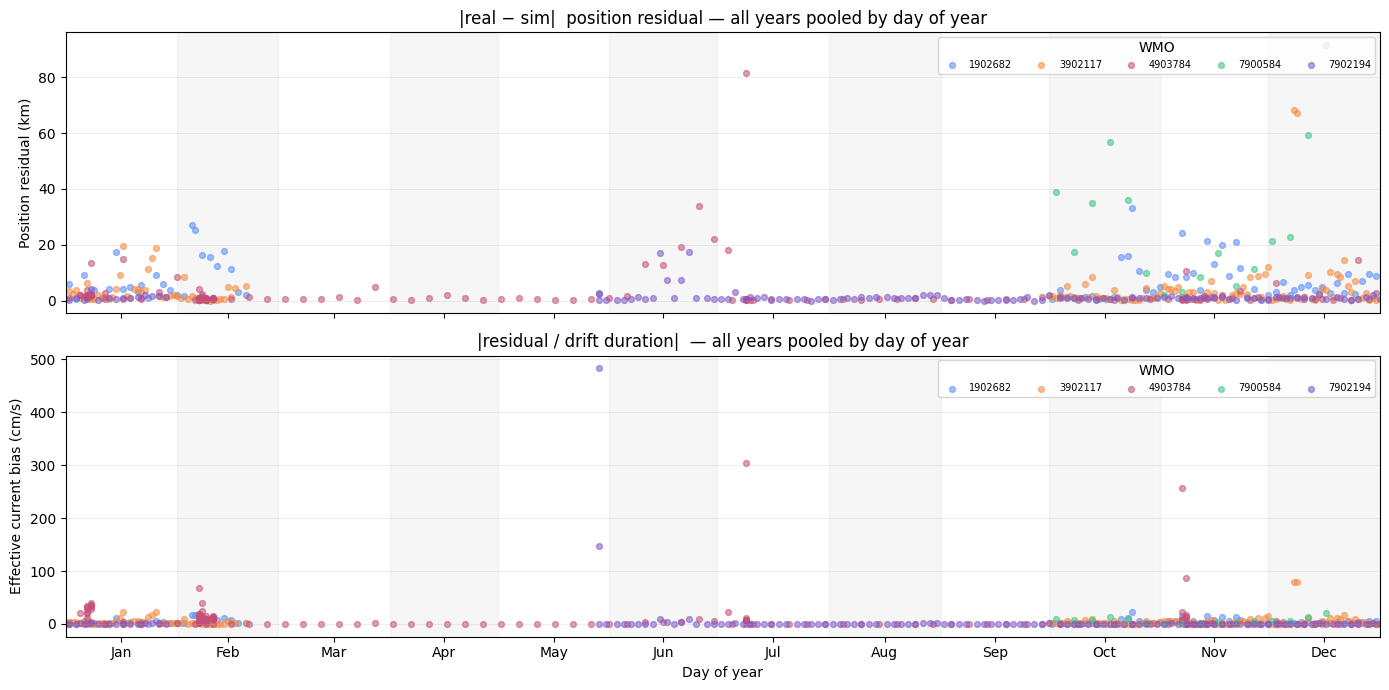

In [27]:
# ── Cell 6b: Seasonal scatter — position residual & current bias vs day-of-year
import matplotlib.pyplot as plt

_month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335, 366]
_month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

colours    = plt.rcParams["axes.prop_cycle"].by_key()["color"]
wmo_list   = sorted(all_df["wmo"].unique())
colour_map = {wmo: colours[i % len(colours)] for i, wmo in enumerate(wmo_list)}

fig, (ax_pos, ax_bias) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for wmo in wmo_list:
    sub     = all_df[all_df["wmo"] == wmo].copy()
    doy     = pd.to_datetime(sub["start_time"]).dt.day_of_year.values
    pos_km  = np.sqrt(sub["x_res_m"].values**2 + sub["y_res_m"].values**2) / 1000.0
    bias_cm = np.sqrt((sub["x_res_m"].values / sub["T_drift_s"].values)**2 +
                      (sub["y_res_m"].values / sub["T_drift_s"].values)**2) * 100.0

    ax_pos.scatter(doy, pos_km,  alpha=0.55, s=18, color=colour_map[wmo], label=str(wmo))
    ax_bias.scatter(doy, bias_cm, alpha=0.55, s=18, color=colour_map[wmo], label=str(wmo))

for ax in (ax_pos, ax_bias):
    # shade alternate months for readability
    for k in range(12):
        if k % 2 == 1:
            ax.axvspan(_month_starts[k], _month_starts[k + 1],
                       color="grey", alpha=0.07, zorder=0)
    ax.set_xticks([(_month_starts[k] + _month_starts[k + 1]) / 2 for k in range(12)])
    ax.set_xticklabels(_month_labels)
    ax.set_xlim(1, 366)
    ax.grid(axis="y", lw=0.4, alpha=0.4)
    ax.legend(title="WMO", fontsize=7, ncol=len(wmo_list), loc="upper right")

ax_pos.set_ylabel("Position residual (km)")
ax_pos.set_title("|real − sim|  position residual — all years pooled by day of year")

ax_bias.set_ylabel("Effective current bias (cm/s)")
ax_bias.set_title("|residual / drift duration|  — all years pooled by day of year")
ax_bias.set_xlabel("Day of year")

plt.tight_layout()
plt.show()

In [28]:
# ── Cell 6c: Map of high-error cycles — trajectories + error vectors ──────────
import plotly.graph_objects as go
import plotly.express as px

TOP_N = 25   # number of highest-error cycles to highlight

# Reconstruct cycle start positions from the preceding cycle's real end
df_s = all_df.sort_values(["wmo", "cycle"]).copy()
df_s["cyc_start_lat"] = df_s.groupby("wmo")["real_lat"].shift(1)
df_s["cyc_start_lon"] = df_s.groupby("wmo")["real_lon"].shift(1)

top = df_s.nlargest(TOP_N, "error_km").copy()

# Colour palette — one colour per WMO
palette   = px.colors.qualitative.Plotly
wmo_list  = sorted(all_df["wmo"].unique())
wmo_color = {wmo: palette[i % len(palette)] for i, wmo in enumerate(wmo_list)}

# park_mode → marker symbol for error-vector endpoints
mode_symbol = {
    "park_on_bottom":   "square",
    "parking_depth":    "circle",
    "drift_on_surface": "diamond",
}

fig = go.Figure()

# ── Background: all real surfacings per float ─────────────────────────────────
for wmo in wmo_list:
    sub = df_s[df_s["wmo"] == wmo].sort_values("cycle")
    fig.add_trace(go.Scattergeo(
        lon=sub["real_lon"], lat=sub["real_lat"],
        mode="lines+markers",
        line=dict(color=wmo_color[wmo], width=0.8),
        marker=dict(size=4, opacity=0.3, color=wmo_color[wmo]),
        name=f"WMO {wmo}",
        legendgroup=str(wmo),
        showlegend=True,
        hovertemplate=f"WMO {wmo}<br>%{{lat:.3f}}°N %{{lon:.3f}}°E<extra></extra>",
    ))

# ── Top-N cycles: start → sim_end (orange dash) & start → real_end (blue dash)
for _, row in top.iterrows():
    has_start = not (pd.isna(row["cyc_start_lat"]) or pd.isna(row["cyc_start_lon"]))
    label = (f"WMO {row['wmo']} C{int(row['cycle'])}  "
             f"{row['error_km']:.0f} km  [{row['park_mode']}]")
    sym = mode_symbol.get(row["park_mode"], "circle")

    if has_start:
        # Predicted path: start → sim_end
        fig.add_trace(go.Scattergeo(
            lon=[row["cyc_start_lon"], row["sim_lon"]],
            lat=[row["cyc_start_lat"], row["sim_lat"]],
            mode="lines", line=dict(color="orange", width=1.5, dash="dot"),
            showlegend=False, hoverinfo="skip",
        ))
        # Real path: start → real_end
        fig.add_trace(go.Scattergeo(
            lon=[row["cyc_start_lon"], row["real_lon"]],
            lat=[row["cyc_start_lat"], row["real_lat"]],
            mode="lines", line=dict(color="deepskyblue", width=1.5, dash="dot"),
            showlegend=False, hoverinfo="skip",
        ))

    # Error vector: sim_end → real_end  (red line)
    fig.add_trace(go.Scattergeo(
        lon=[row["sim_lon"], row["real_lon"]],
        lat=[row["sim_lat"], row["real_lat"]],
        mode="lines+markers",
        line=dict(color="red", width=2),
        marker=dict(
            size=[10, 12],
            symbol=["x", sym],
            color=["orange", "deepskyblue"],
        ),
        name=label,
        legendgroup="errors",
        legendgrouptitle_text="High-error cycles" if _ == top.index[0] else "",
        showlegend=True,
        hovertemplate=(
            f"WMO {row['wmo']}  Cycle {int(row['cycle'])}<br>"
            f"Error: {row['error_km']:.1f} km<br>"
            f"park_mode: {row['park_mode']}<br>"
            f"parked_on_bottom: {row['parked_on_bottom']}<br>"
            f"cycle_hours: {row['cycle_hours']:.1f} h<br>"
            "orange X = sim end  ·  blue = real end<extra></extra>"
        ),
    ))

lat_c = (all_df["real_lat"].mean())
lon_c = (all_df["real_lon"].mean())

fig.update_layout(
    title=f"Top-{TOP_N} error cycles  |  orange X = sim end  ·  blue marker = real end  ·  red line = error vector",
    geo=dict(
        scope="europe",
        center=dict(lat=lat_c, lon=lon_c),
        projection_scale=5,
        showland=True,  landcolor="rgb(40,40,40)",
        showocean=True, oceancolor="rgb(10,30,60)",
        showcoastlines=True, coastlinecolor="grey", showframe=False,
    ),
    paper_bgcolor="rgb(15,20,40)", font_color="white",
    height=650,
    legend=dict(bgcolor="rgba(0,0,0,0.5)", font_size=9),
)
fig.show()

# ── Diagnostic table ───────────────────────────────────────────────────────────
print(f"\nTop-{TOP_N} cycles by position error:")
diag = top[["wmo","cycle","start_time","error_km","park_mode",
            "parked_on_bottom","cycle_hours","T_s"]].copy()
diag["T_h"]        = (diag["T_s"] / 3600).round(1)
diag["error_km"]   = diag["error_km"].round(1)
diag["cycle_hours"]= diag["cycle_hours"].round(1)
diag = diag.drop(columns="T_s").sort_values("error_km", ascending=False)
print(diag.to_string(index=False))


Top-25 cycles by position error:
    wmo  cycle                    start_time  error_km      park_mode  parked_on_bottom  cycle_hours   T_h
7900584     34 2023-12-17T10:51:25.000000000      91.0  parking_depth             False        119.3 120.4
4903784    115 2024-07-08T12:09:03.000000000      81.1 park_on_bottom              True          1.3   7.9
3902117    257 2023-12-08T08:31:00.000000000      68.3  parking_depth             False         23.1  24.0
3902117    258 2023-12-09T08:30:00.000000000      67.2  parking_depth             False         23.0  24.0
7900584     33 2023-12-12T10:57:46.000000000      59.2  parking_depth             False        119.1 119.9
7900584     22 2023-10-18T10:49:02.000000000      56.7  parking_depth             False        119.2 120.0
7900584     19 2023-10-03T10:46:19.000000000      38.7  parking_depth             False        119.3 120.2
7900584     23 2023-10-23T10:47:29.000000000      36.1  parking_depth             False        119.6 120.1
790

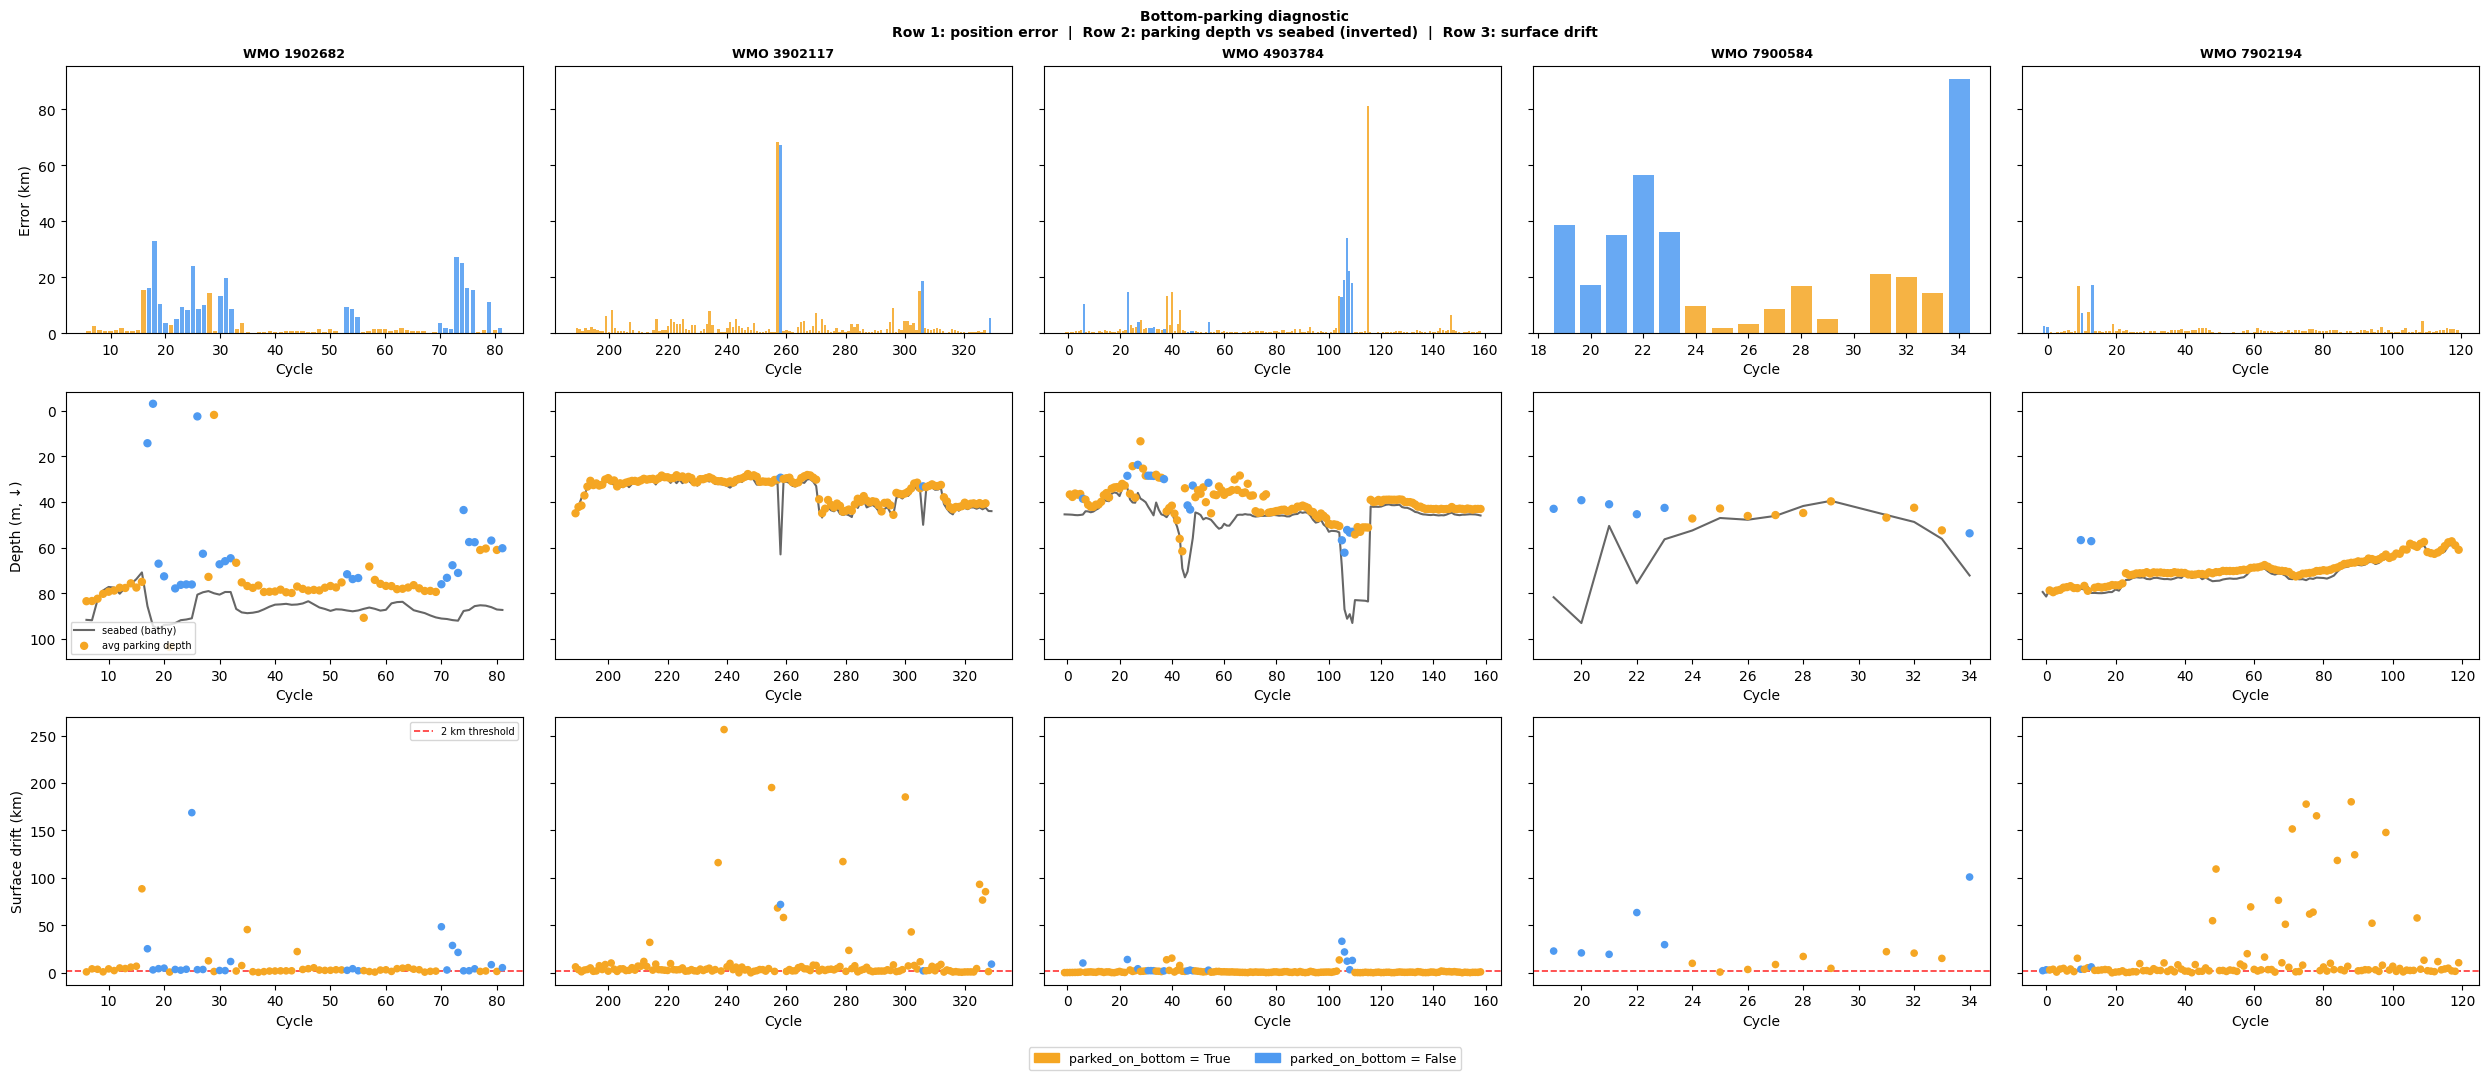

In [13]:
# ── Cell 6d: Bottom-parking diagnostic — one column per float ─────────────────
# Row 1: error_km coloured by parked_on_bottom classification
# Row 2: avg_bottom_depth_dbar (scatter) vs bathy_depth_m (line) — depth axis inverted
# Row 3: drift_km with 2 km threshold — the raw signal driving the classification
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_required = {"avg_bottom_depth_dbar", "bathy_depth_m", "drift_km"}
if not _required.issubset(all_df.columns):
    missing = _required - set(all_df.columns)
    raise RuntimeError(
        f"Columns {missing} missing from all_df. "
        "Set FORCE_RERUN = True in Cell 6 and re-run it to rebuild the cache."
    )

wmo_list = sorted(all_df["wmo"].unique())
n = len(wmo_list)

C_PARK  = "#f5a623"   # orange  — parked_on_bottom = True
C_DRIFT = "#4e9af1"   # blue    — parked_on_bottom = False

fig, axes = plt.subplots(3, n, figsize=(5 * n, 11), sharey="row")
if n == 1:
    axes = axes.reshape(3, 1)

fig.suptitle(
    "Bottom-parking diagnostic\n"
    "Row 1: position error  |  Row 2: parking depth vs seabed (inverted)  |  Row 3: surface drift",
    fontsize=10, fontweight="bold",
)

for col, wmo in enumerate(wmo_list):
    sub = all_df[all_df["wmo"] == wmo].sort_values("cycle").copy()
    cyc = sub["cycle"].values
    err = sub["error_km"].values
    pob = sub["parked_on_bottom"].values
    colours = np.where(pob, C_PARK, C_DRIFT)

    ax1, ax2, ax3 = axes[0, col], axes[1, col], axes[2, col]

    # ── Row 1: error_km ───────────────────────────────────────────────────────
    ax1.bar(cyc, err, color=colours, width=0.8, alpha=0.85)
    ax1.set_title(f"WMO {wmo}", fontsize=9, fontweight="bold")
    ax1.set_ylabel("Error (km)" if col == 0 else "")
    ax1.set_xlabel("Cycle")

    # ── Row 2: parking depth vs seabed ───────────────────────────────────────
    park_d = sub["avg_bottom_depth_dbar"].values.astype(float)
    bathy  = sub["bathy_depth_m"].values.astype(float)

    valid_b = ~np.isnan(bathy)
    if valid_b.any():
        ax2.plot(cyc[valid_b], bathy[valid_b], color="black", lw=1.5,
                 alpha=0.6, label="seabed (bathy)", zorder=2)

    valid_p = ~np.isnan(park_d)
    ax2.scatter(cyc[valid_p], park_d[valid_p], c=colours[valid_p],
                s=25, zorder=3, label="avg parking depth")

    ax2.invert_yaxis()
    ax2.set_ylabel("Depth (m, ↓)" if col == 0 else "")
    ax2.set_xlabel("Cycle")
    if col == 0:
        ax2.legend(fontsize=7, loc="lower left")

    # ── Row 3: drift_km ───────────────────────────────────────────────────────
    drift   = sub["drift_km"].values.astype(float)
    valid_d = ~np.isnan(drift)
    ax3.scatter(cyc[valid_d], drift[valid_d], c=colours[valid_d], s=20, zorder=3)
    ax3.axhline(2.0, color="red", lw=1.2, linestyle="--", alpha=0.8,
                label="2 km threshold")
    ax3.set_ylabel("Surface drift (km)" if col == 0 else "")
    ax3.set_xlabel("Cycle")
    if col == 0:
        ax3.legend(fontsize=7)

legend_patches = [
    mpatches.Patch(color=C_PARK,  label="parked_on_bottom = True"),
    mpatches.Patch(color=C_DRIFT, label="parked_on_bottom = False"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           fontsize=9, framealpha=0.8, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [14]:
# ── Cell 7: Visualisation ─────────────────────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

wmos_done = [w for w in WMOS_TO_ANALYZE if w in all_results and all_results[w]]

# ── 1. Box plot: error distribution per float ─────────────────────────────────
fig1 = go.Figure()
for wmo in wmos_done:
    errs = [r["error_km"] for r in all_results[wmo]]
    fig1.add_trace(go.Box(
        y=errs, name=str(wmo),
        boxpoints="all", jitter=0.3, pointpos=-1.8,
        hovertemplate="Error: %{y:.2f} km<extra>WMO " + str(wmo) + "</extra>",
    ))
fig1.update_layout(
    title="Single-cycle position error by float (reset mode)",
    yaxis_title="Error (km)",
    xaxis_title="Float WMO",
    paper_bgcolor="rgb(15,20,40)", font_color="white", plot_bgcolor="rgb(20,30,50)",
    height=420,
)
fig1.show()

# ── 2. Per-cycle error vs cycle index ─────────────────────────────────────────
fig2 = go.Figure()
for wmo in wmos_done:
    rows = all_results[wmo]
    fig2.add_trace(go.Scatter(
        x=[r["cycle"] for r in rows],
        y=[r["error_km"] for r in rows],
        mode="lines+markers", name=str(wmo),
        hovertemplate="Cycle %{x} — %{y:.2f} km<extra>WMO " + str(wmo) + "</extra>",
    ))
fig2.update_layout(
    title="Per-cycle position error vs cycle number",
    xaxis_title="Cycle number",
    yaxis_title="Error (km)",
    paper_bgcolor="rgb(15,20,40)", font_color="white", plot_bgcolor="rgb(20,30,50)",
    legend=dict(bgcolor="rgba(0,0,0,0.5)"),
    height=420,
)
fig2.show()

# ── 3. Summary table ──────────────────────────────────────────────────────────
rows = []
for wmo in wmos_done:
    errs = [r["error_km"] for r in all_results[wmo]]
    rows.append({
        "WMO": wmo,
        "N cycles": len(errs),
        "Mean (km)": round(np.mean(errs), 2),
        "Median (km)": round(np.median(errs), 2),
        "P90 (km)": round(np.percentile(errs, 90), 2),
        "Max (km)": round(np.max(errs), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))

    WMO  N cycles  Mean (km)  Median (km)  P90 (km)  Max (km)
7902194       121       1.31         0.89      1.87     17.42
4903784       160       2.49         0.69      3.33     81.06
1902682        76       5.01         1.37     15.60     33.05
7900584        15      25.09        17.38     49.51     91.03
3902117       141       2.99         1.30      4.95     68.29


## Q estimation — pooled across all floats

Uses the Cartesian residuals and cycle durations captured in Cell 6.  
**Only free-drifting cycles** (`parked_on_bottom == False`) are included — bottom-parked floats are anchored and contribute no current-driven uncertainty.

- **Q_pos** — pooled estimator `mean(ε²/T)` with scatter coloured by WMO; per-float estimates in the summary table let you check inter-float consistency.  
- **Q_bias** — successive bias increments `var(Δb̂)/T̄`; bias time-series per float reveal whether the "apparent current error" is geographically or temporally structured.

Drifting cycles: 54 / 513 total  (5 floats)
Q_pos_x = 2167.7203 m²/s  (σ = 2793.5 m/√hr)
Q_pos_y = 949.1022 m²/s  (σ = 1848.5 m/√hr)
Q_pos   = 1558.4113 m²/s  (pooled isotropic, σ = 2368.6 m/√hr)
Current: Q_pos = 4.0000 m²/s  (σ = 120 m/√hr)


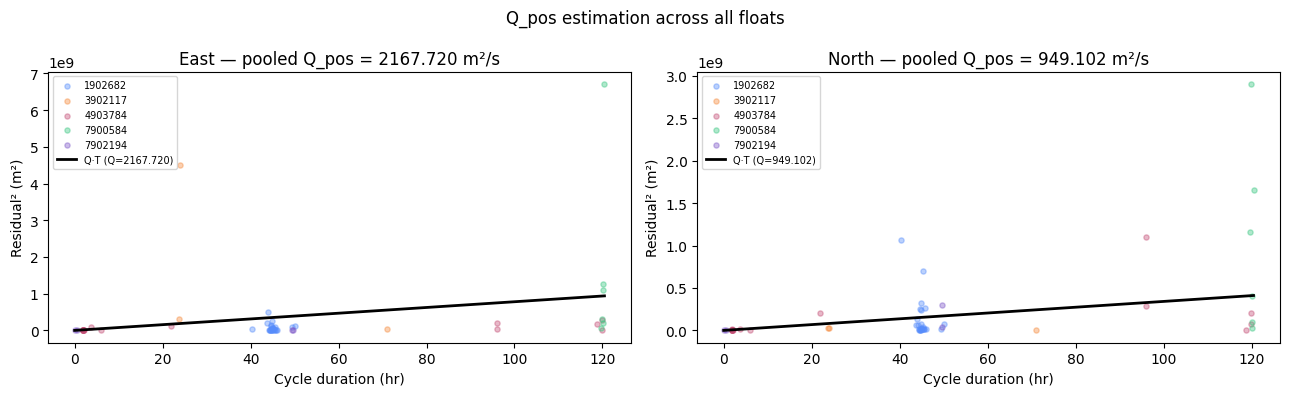

In [15]:
# ── Cell 9: Q_pos — pooled scatter coloured by float ──────────────────────────
import matplotlib.pyplot as plt

df_drifting = all_df[all_df["parked_on_bottom"] == False].copy()
print(f"Drifting cycles: {len(df_drifting)} / {len(all_df)} total  "
      f"({df_drifting['wmo'].nunique()} floats)")

T  = df_drifting["T_s"].values
xr = df_drifting["x_res_m"].values
yr = df_drifting["y_res_m"].values

Q_pos_x = np.mean(xr**2 / T)
Q_pos_y = np.mean(yr**2 / T)
Q_pos   = (Q_pos_x + Q_pos_y) / 2

print(f"Q_pos_x = {Q_pos_x:.4f} m²/s  (σ = {np.sqrt(Q_pos_x)*60:.1f} m/√hr)")
print(f"Q_pos_y = {Q_pos_y:.4f} m²/s  (σ = {np.sqrt(Q_pos_y)*60:.1f} m/√hr)")
print(f"Q_pos   = {Q_pos:.4f} m²/s  (pooled isotropic, σ = {np.sqrt(Q_pos)*60:.1f} m/√hr)")
print(f"Current: Q_pos = {(120/60)**2:.4f} m²/s  (σ = 120 m/√hr)")

T_line = np.linspace(0, T.max(), 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]
wmo_list = sorted(df_drifting["wmo"].unique())
colour_map = {wmo: colours[i % len(colours)] for i, wmo in enumerate(wmo_list)}

for ax, res, Q_ax, label in [
    (axes[0], xr, Q_pos_x, "East"),
    (axes[1], yr, Q_pos_y, "North"),
]:
    for wmo in wmo_list:
        mask = df_drifting["wmo"].values == wmo
        ax.scatter(T[mask] / 3600, res[mask]**2,
                   alpha=0.4, s=14, color=colour_map[wmo], label=str(wmo))
    ax.plot(T_line / 3600, Q_ax * T_line, "k-", lw=2, label=f"Q·T (Q={Q_ax:.3f})")
    ax.set_xlabel("Cycle duration (hr)")
    ax.set_ylabel("Residual² (m²)")
    ax.set_title(f"{label} — pooled Q_pos = {Q_ax:.3f} m²/s")
    ax.legend(fontsize=7)
plt.suptitle("Q_pos estimation across all floats")
plt.tight_layout()
plt.show()

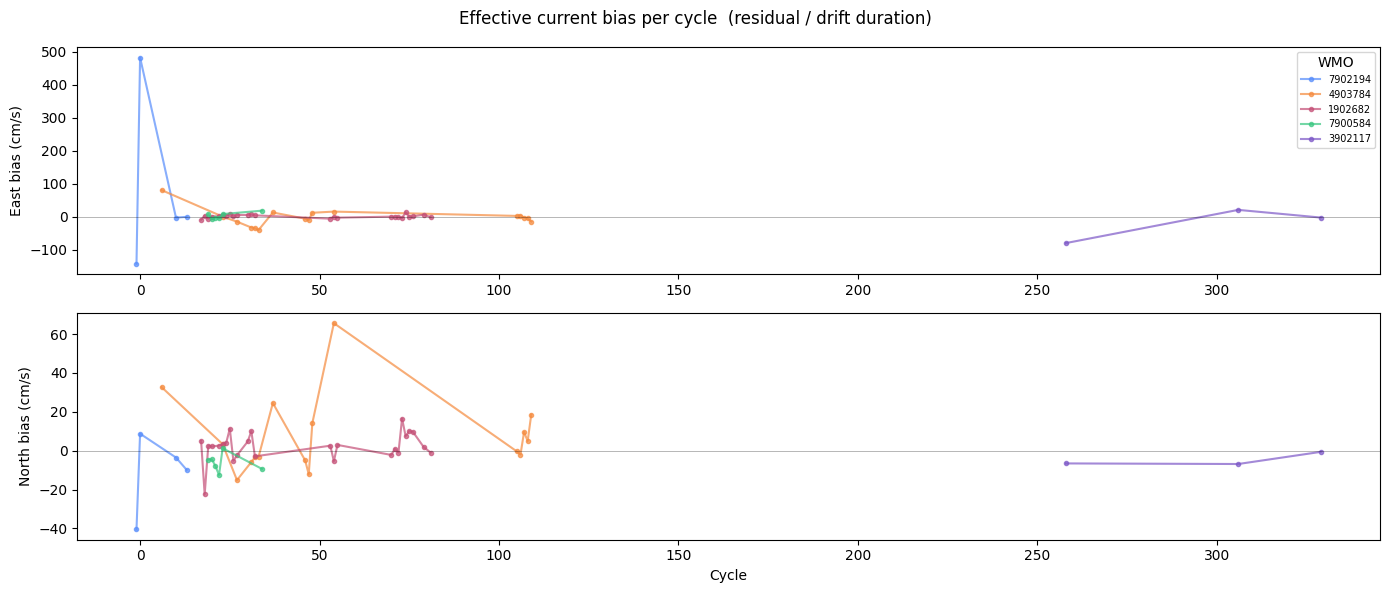

Q_bias (pooled) = 3.7652e-06 (m/s)²/s  (σ = 0.11642 (m/s)/√hr)
Current default = 6.9444e-05 (m/s)²/s


In [16]:
# ── Cell 10: Q_bias — pooled + per-float ──────────────────────────────────────
import matplotlib.pyplot as plt

per_float_Q = {}   # wmo → (Q_pos, Q_bias)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for wmo in WMOS_TO_ANALYZE:
    sub = df_drifting[df_drifting["wmo"] == wmo].sort_values("cycle")
    if len(sub) < 3:
        continue

    bx = (sub["x_res_m"] / sub["T_drift_s"]).values
    by = (sub["y_res_m"] / sub["T_drift_s"]).values
    T_arr = sub["T_drift_s"].values
    T_mean = np.mean(T_arr[:-1])

    delta_bx = np.diff(bx)
    delta_by = np.diff(by)
    Q_bias_x_w = np.var(delta_bx) / T_mean
    Q_bias_y_w = np.var(delta_by) / T_mean
    Q_pos_w    = (np.mean(sub["x_res_m"].values**2 / sub["T_s"].values) +
                  np.mean(sub["y_res_m"].values**2 / sub["T_s"].values)) / 2
    per_float_Q[wmo] = (Q_pos_w, (Q_bias_x_w + Q_bias_y_w) / 2)

    axes[0].plot(sub["cycle"], bx * 100, ".-", alpha=0.7, label=str(wmo))
    axes[1].plot(sub["cycle"], by * 100, ".-", alpha=0.7, label=str(wmo))

axes[0].axhline(0, color="black", lw=0.5, alpha=0.4)
axes[0].set_ylabel("East bias (cm/s)")
axes[0].legend(title="WMO", fontsize=7)
axes[1].axhline(0, color="black", lw=0.5, alpha=0.4)
axes[1].set_ylabel("North bias (cm/s)")
axes[1].set_xlabel("Cycle")
plt.suptitle("Effective current bias per cycle  (residual / drift duration)")
plt.tight_layout()
plt.show()

# Pooled Q_bias
bx_all = (df_drifting["x_res_m"] / df_drifting["T_drift_s"]).values
by_all = (df_drifting["y_res_m"] / df_drifting["T_drift_s"]).values
T_mean_all = np.mean(df_drifting["T_drift_s"].values)
Q_bias = ((np.var(np.diff(bx_all)) + np.var(np.diff(by_all))) / 2) / T_mean_all
print(f"Q_bias (pooled) = {Q_bias:.4e} (m/s)²/s  "
      f"(σ = {np.sqrt(Q_bias)*60:.5f} (m/s)/√hr)")
print(f"Current default = {(0.5/60)**2:.4e} (m/s)²/s")

In [17]:
# ── Cell 11: Q summary — pooled estimate ready to paste into noise.py ─────────
sigma_pos_m_per_sqrt_hr    = np.sqrt(Q_pos)  * 60
sigma_bias_ms_per_sqrt_hr  = np.sqrt(Q_bias) * 60

print("=" * 55)
print("POOLED Q ESTIMATE — paste into src/noise.py")
print("=" * 55)
print(f"""
_SIGMA_POS  = {sigma_pos_m_per_sqrt_hr:.2f} / 60   # {sigma_pos_m_per_sqrt_hr:.1f} m/√hr  → Q_pos  = {Q_pos:.4f} m²/s
_SIGMA_BIAS = {sigma_bias_ms_per_sqrt_hr:.6f} / 60  # {sigma_bias_ms_per_sqrt_hr:.6f} (m/s)/√hr → Q_bias = {Q_bias:.4e} (m/s)²/s
""")
print("Compared to current defaults:")
print(f"  Q_pos  : {(120/60)**2:.4f}  →  {Q_pos:.4f}  m²/s          (ratio {Q_pos/(120/60)**2:.2f}x)")
print(f"  Q_bias : {(0.5/60)**2:.4e}  →  {Q_bias:.4e} (m/s)²/s  (ratio {Q_bias/(0.5/60)**2:.2f}x)")

# Per-float table
print("\nPer-float estimates:")
tbl = []
for wmo in per_float_Q:
    qp, qb = per_float_Q[wmo]
    n = (all_df["wmo"] == wmo).sum()
    tbl.append({"WMO": wmo, "N drifting": n,
                "Q_pos (m²/s)": round(qp, 4),
                "σ_pos (m/√hr)": round(np.sqrt(qp)*60, 1),
                "Q_bias (m/s)²/s": f"{qb:.2e}"})
print(pd.DataFrame(tbl).to_string(index=False))

POOLED Q ESTIMATE — paste into src/noise.py

_SIGMA_POS  = 2368.60 / 60   # 2368.6 m/√hr  → Q_pos  = 1558.4113 m²/s
_SIGMA_BIAS = 0.116425 / 60  # 0.116425 (m/s)/√hr → Q_bias = 3.7652e-06 (m/s)²/s

Compared to current defaults:
  Q_pos  : 4.0000  →  1558.4113  m²/s          (ratio 389.60x)
  Q_bias : 6.9444e-05  →  3.7652e-06 (m/s)²/s  (ratio 0.05x)

Per-float estimates:
    WMO  N drifting  Q_pos (m²/s)  σ_pos (m/√hr) Q_bias (m/s)²/s
7902194         121     2082.2400         2737.9        1.74e-04
4903784         160      773.1676         1668.4        5.23e-07
1902682          76      670.8674         1554.1        5.07e-08
7900584          15     3067.2102         3322.9        2.12e-08
3902117         141     9426.5397         5825.4        2.28e-06
